
# Insurance Portfolio Analysis

This notebook analyzes the simulated insurance portfolio created for the assignment.

The goal is to understand how **premium revenue and claim costs evolve over time** and evaluate the overall behavior of the portfolio.

### Key analytical questions explored:

- What is the total premium revenue generated?
- When do claims begin to appear in the portfolio?
- How does policy tenure affect claim exposure?
- What insights can be derived about portfolio risk?

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load the Datasets

The following datasets were generated using the simulation script:

- **Policy dataset** containing 1,000,000 policies
- **Claims dataset** containing simulated claims based on assignment rules

In [35]:
policies = pd.read_csv("data/policy_data.csv")
claims = pd.read_csv("data/claims_data.csv")

policies.head()

,Customer_ID,Vehicle_ID,Policy_Purchase_Date,Policy_Tenure,Vehicle_Value,Premium,Policy_Start_Date,Policy_End_Date
0,1,1,2024-05-05,2,100000,200,2025-05-05,2027-05-05
1,2,2,2024-07-13,4,100000,400,2025-07-13,2029-07-12
2,3,3,2024-04-05,3,100000,300,2025-04-05,2028-04-04
3,4,4,2024-07-31,3,100000,300,2025-07-31,2028-07-30
4,5,5,2024-11-19,1,100000,100,2025-11-19,2026-11-19


In [36]:
claims.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Date,Claim_Amount,Claim_Type
0,1,584691,584691,2025-12-21,10000,1
1,2,977583,977583,2025-05-21,10000,1
2,3,224110,224110,2025-11-28,10000,1
3,4,392207,392207,2025-04-07,10000,1
4,5,377768,377768,2025-11-14,10000,1


## Data Validation

Before performing analysis, it is useful to confirm that the generated datasets follow the assignment rules.

In [37]:
print("Number of policies:", len(policies))
print("Number of claims:", len(claims))

# Validate premium rule
(policies["Premium"] == policies["Policy_Tenure"] * 100).all()

Number of policies: 1000000
Number of claims: 49454


np.True_

## Premium Revenue Analysis

Insurance companies collect premiums when policies are purchased.

This section calculates the **total premium collected across the entire portfolio**.

Total Premium Collected: 240110800


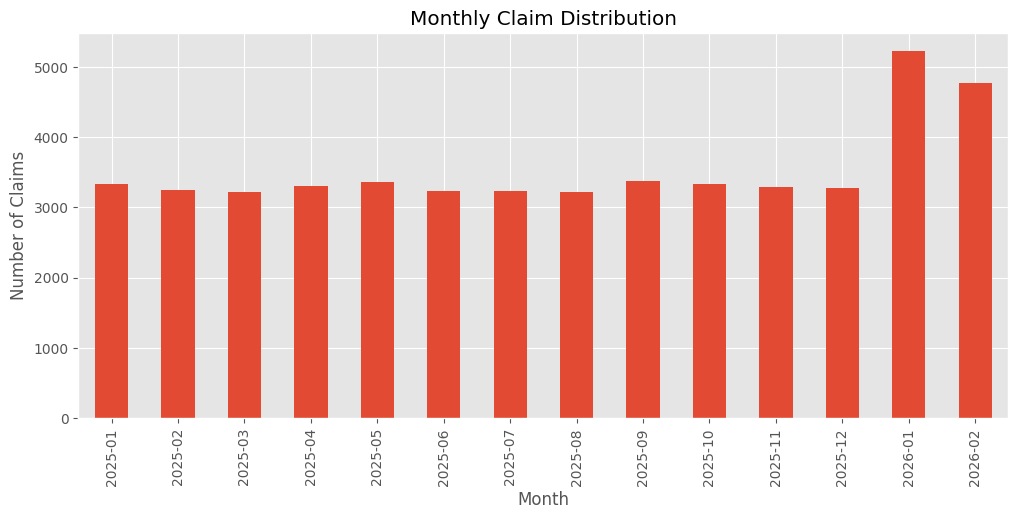

In [38]:
total_premium = policies["Premium"].sum()
print("Total Premium Collected:", total_premium)

claims["Claim_Date"] = pd.to_datetime(claims["Claim_Date"])
claims["Claim_Month"] = claims["Claim_Date"].dt.to_period("M")

claims_by_month = claims.groupby("Claim_Month").size()

plt.figure(figsize=(12,5))
claims_by_month.plot(kind="bar")

plt.title("Monthly Claim Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.grid(True)

plt.show()

## Key Insights

### 1. Claim Clustering After Policy Activation

Although policies were sold throughout 2024, a noticeable spike in claims appears in early 2025.

This occurs because claims are triggered exactly when policies become active (365 days after purchase).

---

### 2. Long Tenure Policies Extend Risk Exposure

Vehicles with **4-year policy tenure** generate additional claims in early 2026.

This illustrates how longer policy durations increase the period of risk exposure.

---

### 3. Revenue vs Risk Timing

Insurance portfolios typically collect revenue upfront while claims occur later.

Understanding this **timing gap between revenue and claims** is essential for evaluating portfolio profitability.

---

## Conclusion

This analysis demonstrates how simulated insurance data can be used to study portfolio behavior.

Even with simplified assumptions, the analysis highlights key insurance analytics concepts such as:

- claim frequency
- claim timing patterns
- loss exposure by policy tenure